# SR3 RV Lab — Framework 7: FOMC event studies, turned into rules

**RV class: D — event speed.**

For every FOMC meeting in the sample, measure in the ±5 business-day window
which market moved first:

* the **futures** calendar spread (the linear leg),
* the **wing premiums** (the skew leg),
* the **listed digitals** (the probability leg).

If one leads another systematically, that lead is a rule. This notebook builds
the event panel, tests the lead-lag with a plain cross-correlation and a
regression of each market's t+1 change on the others' t change, and then
backtests whatever it finds. If nothing leads, that is the finding and the
framework is recorded as dead rather than dressed up.

In [1]:
CONFIG = dict(
    window=5,                 # business days either side of the meeting
    wing_offset=0.25,
    strike_tol=0.13,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=2.5,
    entry_offsets=(-5, -3, -1),   # business days before the meeting to enter
    holds=(2, 5, 10),
)
CONFIG

{'window': 5,
 'wing_offset': 0.25,
 'strike_tol': 0.13,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'entry_offsets': (-5, -3, -1),
 'holds': (2, 5, 10)}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, header_block, league_row, load_lab
from RVUtils.SFRRVLab import (
    FOMC_DATES, Leg, Structure, add_event_distance, constant_maturity_slots,
    contract_pairs, quarterly_sort_key, risk_reversal_panel, run_backtest,
    vertical_digital,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]
contracts = contracts.merge(
    constant_maturity_slots(contracts)[["as_of", "symbol", "cm_slot"]],
    on=["as_of", "symbol"], how="left")
live = contracts[contracts["tte"] >= CONFIG["min_tte"]]

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


## Build the three daily series per contract

In [3]:
fwd = contracts.set_index(["as_of", "symbol"])["forward_rate"]
fwd_px = contracts.set_index(["as_of", "symbol"])["forward_price"]
rr = risk_reversal_panel(quotes, contracts, offset=CONFIG["wing_offset"],
                         tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
QDAY = {k: v for k, v in quotes.groupby(["as_of", "symbol"], sort=False)}

dig_rows = []
for (ts, sym), g in QDAY.items():
    f = fwd.get((ts, sym))
    fp = fwd_px.get((ts, sym))
    if f is None or not np.isfinite(f):
        continue
    d = vertical_digital(g[g["oi"] >= CONFIG["min_oi"]], float(f) + 0.25,
                         tol=0.10, forward_price=float(fp))
    if d is None or not (-0.02 <= d["prob"] <= 1.02):
        continue
    dig_rows.append({"as_of": ts, "symbol": sym, "dig_up25": d["prob"]})
dig = pd.DataFrame(dig_rows)

series = (live[["as_of", "symbol", "forward_rate", "cm_slot"]]
          .merge(rr[["as_of", "symbol", "rr_bp"]], on=["as_of", "symbol"], how="inner")
          .merge(dig, on=["as_of", "symbol"], how="inner"))
series["rate_bp"] = series["forward_rate"] * 100.0
series = add_event_distance(series)
print(f"event series: {len(series)} rows, {series['symbol'].nunique()} symbols, "
      f"{series['nearest_fomc'].nunique()} meetings")

event series: 3675 rows, 14 symbols, 18 meetings


## Daily changes and the lead-lag test

All three are differenced so the regression is on innovations, not levels.

In [4]:
S = series.sort_values(["symbol", "as_of"]).copy()
for c in ("rate_bp", "rr_bp", "dig_up25"):
    S[f"d_{c}"] = S.groupby("symbol")[c].diff()
S = S.dropna(subset=["d_rate_bp", "d_rr_bp", "d_dig_up25"])
print(S[["d_rate_bp", "d_rr_bp", "d_dig_up25"]].describe().round(4).to_string())

       d_rate_bp    d_rr_bp  d_dig_up25
count   3661.000  3661.0000   3661.0000
mean       0.086     0.0057     -0.0008
std        5.937     3.0588      0.0349
min      -41.000   -10.0000     -0.3200
25%       -3.000    -1.7500     -0.0200
50%        0.000     0.0000      0.0000
75%        3.500     1.7500      0.0200
max       30.500     9.7500      0.2800


In [5]:
print("\nCONTEMPORANEOUS correlation of daily changes")
print(S[["d_rate_bp", "d_rr_bp", "d_dig_up25"]].corr().round(3).to_string())

print("\nLEAD-LAG: corr(x_t, y_{t+1}) — a market that LEADS predicts the other's "
      "next move")
lead = {}
for a in ("d_rate_bp", "d_rr_bp", "d_dig_up25"):
    for b in ("d_rate_bp", "d_rr_bp", "d_dig_up25"):
        vals = []
        for sym, sub in S.groupby("symbol"):
            x = sub[a].to_numpy()[:-1]
            y = sub[b].to_numpy()[1:]
            if len(x) > 30 and np.std(x) > 0 and np.std(y) > 0:
                vals.append(np.corrcoef(x, y)[0, 1])
        lead[(a, b)] = np.nanmean(vals) if vals else np.nan
ll = pd.DataFrame(
    [[lead[(a, b)] for b in ("d_rate_bp", "d_rr_bp", "d_dig_up25")]
     for a in ("d_rate_bp", "d_rr_bp", "d_dig_up25")],
    index=[f"{a}_t" for a in ("rate", "rr", "dig")],
    columns=[f"{b}_t+1" for b in ("rate", "rr", "dig")])
print(ll.round(3).to_string())
print("\nDiagonal entries are each series' own autocorrelation; off-diagonal "
      "entries are the cross-market lead. Anything below ~0.05 in absolute "
      "value is not a tradeable lead at daily frequency.")


CONTEMPORANEOUS correlation of daily changes
            d_rate_bp  d_rr_bp  d_dig_up25
d_rate_bp       1.000    0.033      -0.092
d_rr_bp         0.033    1.000      -0.281
d_dig_up25     -0.092   -0.281       1.000

LEAD-LAG: corr(x_t, y_{t+1}) — a market that LEADS predicts the other's next move
        rate_t+1  rr_t+1  dig_t+1
rate_t    -0.032  -0.009    0.015
rr_t      -0.005  -0.494    0.145
dig_t     -0.007   0.148   -0.423

Diagonal entries are each series' own autocorrelation; off-diagonal entries are the cross-market lead. Anything below ~0.05 in absolute value is not a tradeable lead at daily frequency.


## Event-window behaviour

Average absolute daily change by business-day distance from the meeting,
normalised by each series' own full-sample standard deviation so the three are
comparable.

In [6]:
ev = S[S["days_to_fomc"].between(-CONFIG["window"], CONFIG["window"])].copy()
prof = []
for c in ("d_rate_bp", "d_rr_bp", "d_dig_up25"):
    sd = S[c].std()
    g = ev.groupby("days_to_fomc")[c].apply(lambda s: s.abs().mean() / sd)
    prof.append(g.rename(c))
prof = pd.concat(prof, axis=1)
print(prof.round(3).to_string())

              d_rate_bp  d_rr_bp  d_dig_up25
days_to_fomc                                
-5                0.693    0.774       0.742
-3                0.313    1.109       0.327
-2                0.467    0.639       0.560
-1                0.605    0.778       0.560
 0                0.944    0.750       0.681
 1                0.933    0.777       0.698
 2                0.942    0.648       0.575
 4                1.081    0.858       0.668
 5                0.888    0.817       0.721


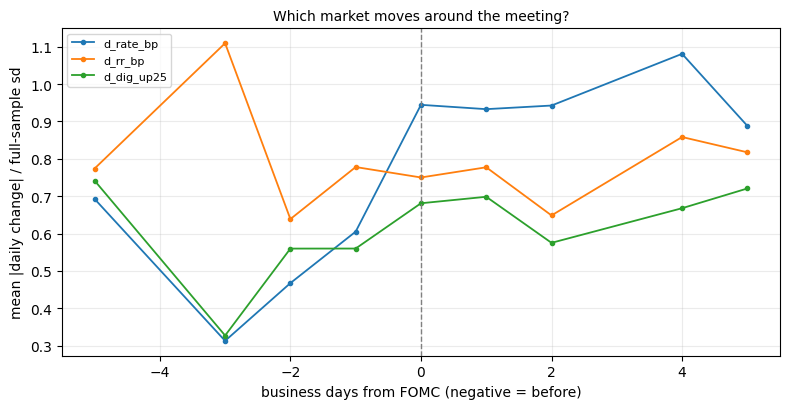

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for c in prof.columns:
    ax.plot(prof.index, prof[c], marker="o", ms=3, lw=1.3, label=c)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("business days from FOMC (negative = before)")
ax.set_ylabel("mean |daily change| / full-sample sd")
ax.set_title("Which market moves around the meeting?", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## The rule: pre-meeting entry, post-meeting exit

Whatever the lead-lag says, the tradeable version of "the two markets reprice
at different speeds" is: put the skew position on N days before the meeting and
take it off after. No z-score, no threshold — the calendar is the signal, which
also means there is nothing to overfit.

In [8]:
SYMS = sorted(series["symbol"].unique(), key=quarterly_sort_key)
RR_IDX = rr.set_index(["symbol", "as_of"]).sort_index()


def builder_rr(key, exec_date, direction):
    try:
        r = RR_IDX.loc[(key, exec_date)]
    except KeyError:
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    return Structure((Leg("option", key, 1.0, "P", float(r["hk_K"])),
                      Leg("option", key, -1.0, "C", float(r["ct_K"]))),
                     label=f"RR {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25,
                 ma=1, zscore_window=20, zscore_min_periods=10,
                 entry_min_zscore=0.0, quality_gate=False)

sig = series.rename(columns={"symbol": "key"})[
    ["key", "as_of", "days_to_fomc"]].copy()
sig["signal"] = 1.0
sig["gate"] = True

rows = []
for off in CONFIG["entry_offsets"]:
    for hold in CONFIG["holds"]:
        for d in ("fade", "momentum"):
            s = sig.copy()
            s["eligible"] = s["days_to_fomc"] == off
            # the calendar IS the signal: enter unconditionally on the eligible
            # bar and hold one side, rather than letting a z-score pick the side
            cfg = dataclasses.replace(BASE, exit_style=f"t{hold}",
                                      entry_rule="always", direction=d)
            r = run_backtest(cfg, signals=s, book=lab["book"], builder=builder_rr)
            rows.append({"entry_day": off, "hold": hold,
                         "side": "short RR" if d == "fade" else "long RR",
                         **{k: r.metrics[k] for k in
                            ("n_trades", "hit_rate", "avg_net_bp", "total_net_bp",
                             "total_net_usd", "sharpe", "max_dd_bp")}})
ev_grid = pd.DataFrame(rows).round(3)
print("FOMC CALENDAR RULE — risk reversal on N days before, off after the hold")
print(ev_grid.sort_values("total_net_bp", ascending=False).to_string(index=False))
print(f"\nmedian total_net_bp across all {len(ev_grid)} calendar variants: "
      f"{ev_grid['total_net_bp'].median():+.2f}bp   "
      f"share positive {(ev_grid['total_net_bp'] > 0).mean():.0%}")

FOMC CALENDAR RULE — risk reversal on N days before, off after the hold
 entry_day  hold     side  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
        -3    10 short RR         7     0.000      -1.788       -12.515      -31288.50  -3.115    -16.907
        -3     5 short RR         7     0.000      -2.076       -14.529      -36323.25  -4.835    -17.354
        -3     2 short RR         7     0.000      -2.294       -16.058      -40144.25 -10.806    -16.257
        -3     2  long RR         7     0.000      -3.099       -21.694      -54236.25 -14.965    -19.178
        -3     5  long RR         7     0.000      -3.324       -23.270      -58175.75  -8.943    -20.753
        -3    10  long RR         7     0.000      -3.624       -25.368      -63421.00  -5.783    -22.852
        -1    10 short RR       107     0.009      -2.461      -263.280     -658201.00  -4.928   -275.694
        -1     2 short RR       107     0.000      -2.583      -276.340     -690

In [9]:
best = ev_grid.sort_values("total_net_bp", ascending=False).iloc[0]
s = sig.copy()
s["eligible"] = s["days_to_fomc"] == best["entry_day"]
cfg = dataclasses.replace(BASE, exit_style=f"t{int(best['hold'])}",
                          entry_rule="always",
                          direction="fade" if best["side"] == "short RR" else "momentum")
res = run_backtest(cfg, signals=s, book=lab["book"], builder=builder_rr)
header_block("7. FOMC calendar rule (best variant)", res, grid=ev_grid.rename(
    columns={"total_net_bp": "total_net_bp", "sharpe": "sharpe"}))

7. FOMC calendar rule (best variant)  |  fade|ma1|w20|z0.0|t10|lag1|every1|always|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades     7   skipped    0   hit 0%   avg -1.788bp   avg hold 10.0d   stale 0.0%
  total     -12.52bp   $     -31,288   gross +4.98bp
  daily-MTM Sharpe -3.11   maxDD -16.91bp ($-42,268)   worst trade -2.33bp
  t(trade) -10.84   NW t(daily) -1.08   non-overlap SR +nan   DSR p=0.000 over 18 trials


{'n_trades': 7,
 'n_skipped': 0,
 'total_gross_bp': 4.9845999999999995,
 'total_net_bp': -12.5154,
 'total_net_usd': -31288.5,
 'hit_rate': 0.0,
 'avg_net_bp': -1.7879142857142856,
 'sharpe': -3.1149817991738886,
 'max_dd_bp': -16.90738099777964,
 'max_dd_usd': -42268.4524944491,
 'avg_hold_days': 10.0,
 'worst_bp': -2.3278,
 't_stat': -10.84083824209729,
 'n_days': 19,
 'avg_stale': 0.0,
 'pkg_contracts': 2.0,
 'nonoverlap_sharpe': nan,
 'nw_t': -1.084719772229851,
 'dsr_prob': 6.34510000100436e-07,
 'sr_annualised': -3.1149817991738886,
 'n_trials': 18}

In [10]:
league_row("7. FOMC event rule (RR around meetings)", "best-variant", res,
           grid=ev_grid, cls="D",
           note=f"enter {int(best['entry_day'])}d before, hold "
                f"{int(best['hold'])}d, {best['side']}")
med = ev_grid.iloc[(ev_grid["total_net_bp"]
                    - ev_grid["total_net_bp"].median()).abs().argmin()]
s2 = sig.copy()
s2["eligible"] = s2["days_to_fomc"] == med["entry_day"]
res_med = run_backtest(
    dataclasses.replace(BASE, exit_style=f"t{int(med['hold'])}",
                        entry_rule="always",
                        direction="fade" if med["side"] == "short RR" else "momentum"),
    signals=s2, book=lab["book"], builder=builder_rr)
league_row("7. FOMC event rule (RR around meetings)", "median-variant", res_med,
           grid=ev_grid, cls="D", note="median calendar variant, not selected")


  LEAGUE ROW  7. FOMC event rule (RR around meetings) / best-variant: DEAD (too few trades)  (taker -12.52bp, maker +4.98bp, DSR p=0.000)

  LEAGUE ROW  7. FOMC event rule (RR around meetings) / median-variant: DEAD  (taker -281.85bp, maker -14.35bp, DSR p=0.000)


{'framework': '7. FOMC event rule (RR around meetings)',
 'variant': 'median-variant',
 'class': 'D',
 'config': 'fade|ma1|w20|z0.0|t2|lag1|every1|always|dh',
 'n_trades': 107,
 'hit_rate': 0.0,
 'avg_net_bp': -2.6341532710280373,
 'total_gross_bp': -14.3544,
 'total_net_bp': -281.8544,
 'total_net_usd': -704636.0,
 'net_bp_maker': -14.3544,
 'net_bp_taker': -281.8544,
 'net_usd_taker': -704636.0,
 'sharpe': -16.86775764728087,
 'max_dd_bp': -281.0933391169568,
 'max_dd_usd': -702733.347792392,
 'avg_hold_days': 1.8691588785046729,
 'dsr_prob': 3.797268168413704e-20,
 'grid_median_net_bp': -281.531,
 'nonoverlap_sharpe': -8.611042616955078,
 'verdict': 'DEAD',
 'note': 'median calendar variant, not selected'}